In [1]:
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr

sys.path.append(str(Path.cwd().parents[3]))
from utils.helpers import load_data

### This files creates analysis of the overall performance among students on the exam for each gender and combined.

In [2]:
df = load_data("../data/cleaned_data/IN1020_2023_cleaned_data.csv")
df.head()

Data loaded successfully from ../data/cleaned_data/IN1020_2023_cleaned_data.csv
Shape: (64809, 13)


,exam_start_time,exam_end_time,extra_time_mins,incident_time_mins,gender,student_id,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,candidate_response_code,total_score
0,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg__9164195750 associableHotspot__146705536,63.0
1,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg_IA1701156824392d16c8498-010d-48e2-8773-...,63.0
2,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg__361670718761 associableHotspot45546867419,63.0
3,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg_IA1701156731070520d3d02-90c1-49b6-b58e-...,63.0
4,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg_IA1701156329933eb2abd04-c1f3-401f-847a-...,63.0


In [3]:
df_combined = df.groupby('student_id').agg({
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

df_male = df_combined[df_combined['gender'] == 'M']
df_female = df_combined[df_combined['gender'] == 'F']

In [4]:
df_time = df.groupby('student_id').agg({
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

#add column with time taken to complete the exam in minutes
df_time['time_taken'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)

df_time.head()

,student_id,exam_start_time,exam_end_time,gender,total_score,time_taken
0,1,2023-12-11 08:00:04,2023-12-11 11:50:07,M,69.33,230.05
1,2,2023-12-11 08:00:02,2023-12-11 12:29:29,F,68.50,269.45
2,3,2023-12-11 08:00:02,2023-12-11 11:51:38,F,67.00,231.60
3,4,2023-12-11 08:00:07,2023-12-11 11:41:39,F,48.00,221.53
4,5,2023-12-11 08:00:08,2023-12-11 11:58:49,F,70.00,238.68


In [5]:
# Combined descriptive statistics table
descriptive_stats = pd.DataFrame({
    'Combined': round(df_combined['total_score'].describe(), 2),
    'Male': round(df_male['total_score'].describe(), 2),
    'Female': round(df_female['total_score'].describe(), 2)
})

# Add median row explicitly
median_row = pd.DataFrame({
    'Combined': [round(df_combined['total_score'].median(), 2)],
    'Male': [round(df_male['total_score'].median(), 2)],
    'Female': [round(df_female['total_score'].median(), 2)]
}, index=['median'])

# Add mode row
mode_row = pd.DataFrame({
    'Combined': [round(df_combined['total_score'].mode()[0], 2)],
    'Male': [round(df_male['total_score'].mode()[0], 2)],
    'Female': [round(df_female['total_score'].mode()[0], 2)]
}, index=['mode'])

std_row = pd.DataFrame({
    'Combined': [round(df_combined['total_score'].std(), 2)],
    'Male': [round(df_male['total_score'].std(), 2)],
    'Female': [round(df_female['total_score'].std(), 2)]
}, index=['std'])

# Combine the tables
descriptive_stats = pd.concat([descriptive_stats, median_row, mode_row, std_row])

print("Descriptive Statistics for Total Score:")
descriptive_stats

Descriptive Statistics for Total Score:


,Combined,Male,Female
count,590.00,327.00,263.00
mean,64.04,66.44,61.05
std,13.31,12.86,13.29
min,19.50,19.50,21.15
25%,55.70,59.14,51.25
50%,64.26,66.50,61.66
75%,74.12,76.13,71.25
max,95.50,95.50,90.16
median,64.27,66.50,61.66
mode,62.50,62.50,55.00


### Skewness

<Figure size 1200x800 with 0 Axes>

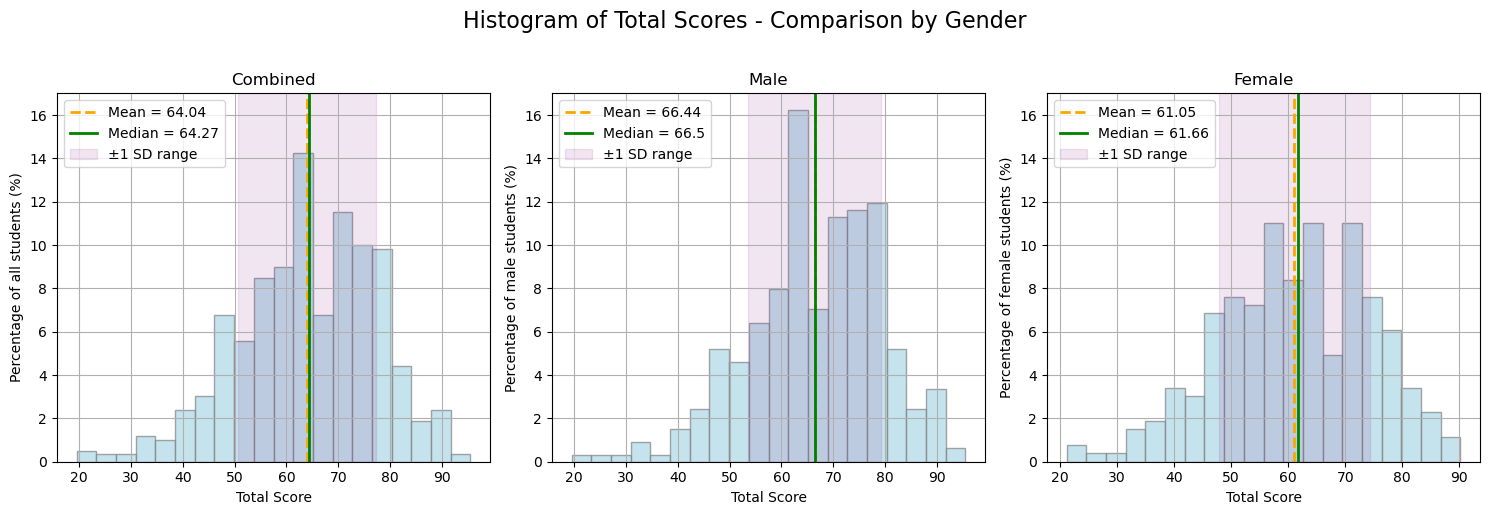

In [6]:
def plot_score_distributions(df, axes, title, ylabel):
    std_combined = round(df['total_score'].std(), 2)
    total_students = len(df)
    axes.hist(df['total_score'], bins=20, color='lightblue', edgecolor='gray', alpha=0.7, weights=np.ones(len(df))/total_students*100)
    axes.axvline(round(df['total_score'].mean(), 2), color='orange', linestyle='--', linewidth=2, label=f'Mean = {round(df["total_score"].mean(), 2)}')
    axes.axvline(round(df['total_score'].median(), 2), color='green', linestyle='-', linewidth=2, label=f'Median = {round(df["total_score"].median(), 2)}')
    axes.axvspan(df['total_score'].mean() - std_combined, df['total_score'].mean() + std_combined, color='purple', alpha=0.1, label='±1 SD range')
    axes.set_xlabel("Total Score")
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.grid(True)
    axes.set_ylim(0, 17)
    axes.legend()

# Combined histogram plot for all three groups with percentage on y-axis
plt.figure(figsize=(12, 8))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Combined histogram - percentage of all students
plot_score_distributions(df_combined, axes[0], "Combined", "Percentage of all students (%)")

# Male histogram - percentage of male students
plot_score_distributions(df_male, axes[1], "Male", "Percentage of male students (%)")

# Female histogram - percentage of female students
plot_score_distributions(df_female, axes[2], "Female", "Percentage of female students (%)")

plt.suptitle("Histogram of Total Scores - Comparison by Gender", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Outliers

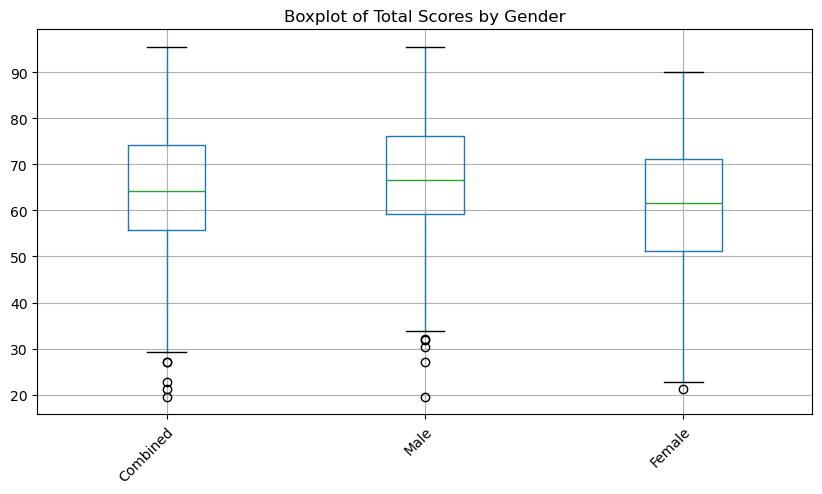

In [7]:
# Boxplot to visualize outliers among points
plt.figure(figsize=(10, 5))
df_outliers = pd.DataFrame({
    'Combined': df_combined['total_score'],
    'Male': df_male['total_score'],
    'Female': df_female['total_score']
})
df_outliers.boxplot()
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.title("Boxplot of Total Scores by Gender")
plt.show()

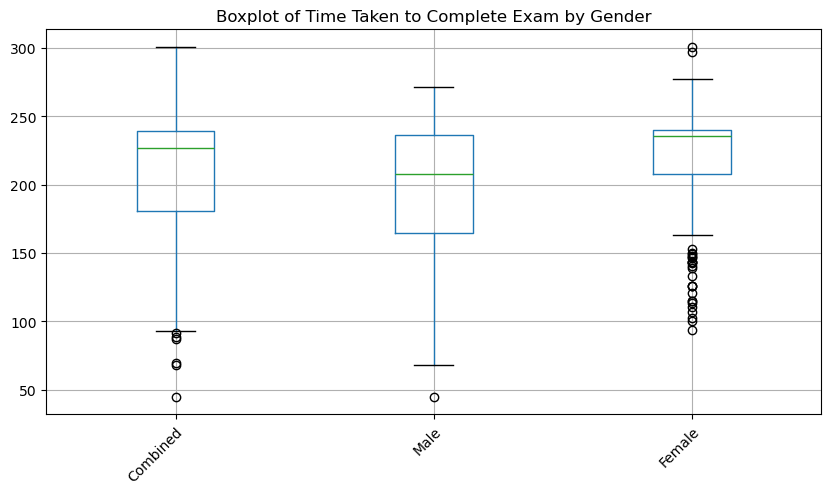

In [8]:
# Boxplot to visualize outliers among time taken
plt.figure(figsize=(10, 5))
df_time_outliers = pd.DataFrame({
    'Combined': df_time['time_taken'],
    'Male': df_time[df_time['gender'] == 'M']['time_taken'],
    'Female': df_time[df_time['gender'] == 'F']['time_taken']
})
df_time_outliers.boxplot()
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.title("Boxplot of Time Taken to Complete Exam by Gender")
plt.show()  

In [9]:
# Pearson correlation between time taken and total score
correlation, p_value = pointbiserialr(df_time['total_score'], df_time['time_taken'])
print(f"Pearson correlation between time taken and total score: {correlation:.4f} (p-value: {p_value:.2f})")


Pearson correlation between time taken and total score: -0.0360 (p-value: 0.38)


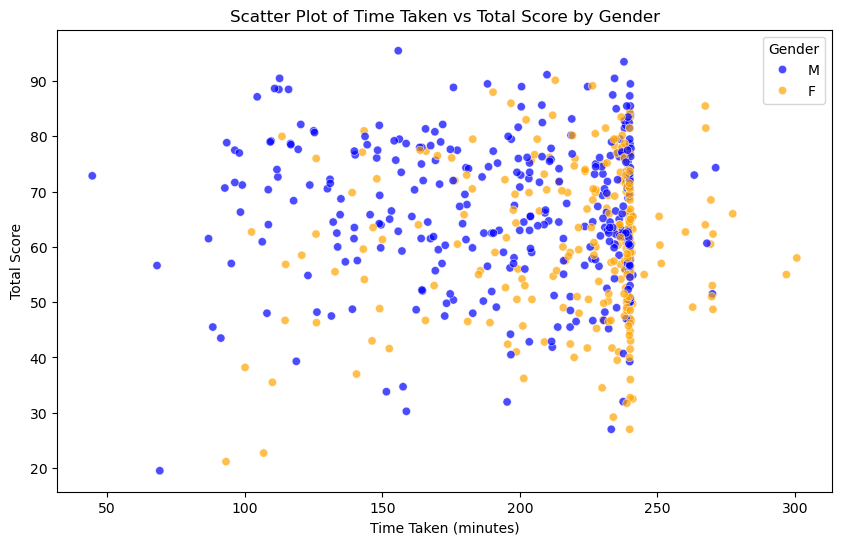

In [10]:
#scatter plot time taken vs total score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_time, x='time_taken', y='total_score', hue='gender', alpha=0.7, palette={'F': 'orange', 'M': 'blue'})
plt.title("Scatter Plot of Time Taken vs Total Score by Gender")
plt.xlabel("Time Taken (minutes)")
plt.ylabel("Total Score")
plt.legend(title='Gender')
plt.show()

/var/folders/14/203xxcn538322g5z2h7l50fm0000gn/T/ipykernel_64795/4084575939.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gender', y='time_taken', data=df_time, palette={'F': 'orange', 'M': 'lightblue'})


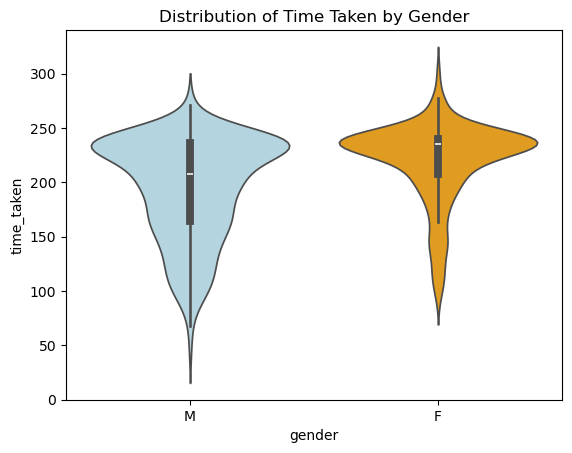

In [11]:
# Violin plot of time by gender
sns.violinplot(x='gender', y='time_taken', data=df_time, palette={'F': 'orange', 'M': 'lightblue'})
plt.title('Distribution of Time Taken by Gender')
plt.show()

/var/folders/14/203xxcn538322g5z2h7l50fm0000gn/T/ipykernel_64795/1077389414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gender', y='total_score', data=df_combined, palette={'F': 'orange', 'M': 'lightblue'})


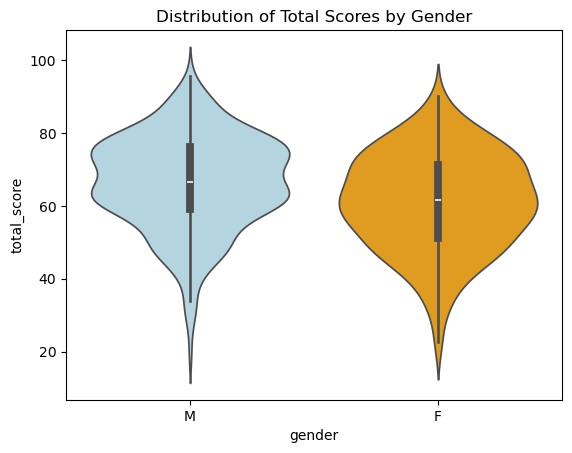

In [12]:
# Violin plot of total scores by gender
sns.violinplot(x='gender', y='total_score', data=df_combined, palette={'F': 'orange', 'M': 'lightblue'})
plt.title('Distribution of Total Scores by Gender')
plt.show()

### Correlation between gender and total score

In [13]:
#point-biserial correlation between gender and total score

# Prepare the data
df_combined['gender_numeric'] = df_combined['gender'].map({'M': 1, 'F': 0})
male_scores = df_combined[df_combined['gender'] == 'M']['total_score']
female_scores = df_combined[df_combined['gender'] == 'F']['total_score']

# Calculate point-biserial correlation
corr, p_value = pointbiserialr(df_combined['gender_numeric'], df_combined['total_score'])
print(f"Point-Biserial Correlation: {corr}, p-value: {p_value}")

if p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")


Point-Biserial Correlation: 0.20126885661963428, p-value: 8.266726799036838e-07
The correlation is statistically significant.
